# Hate Speech Classification

Binary classification of comments (0 = not hate, 1 = hate).

Base model: **HerBERT** (`allegro/herbert-base-cased`), strong on informal Polish.

In [ ]:
!pip install -q transformers peft beautifulsoup4 scikit-learn matplotlib

In [ ]:
!pip install torchao==0.16.0

In [ ]:
import warnings
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy
from bs4 import BeautifulSoup

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from transformers import (
    AutoConfig,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
)
from peft import LoraConfig, TaskType, get_peft_model
import random

warnings.filterwarnings("ignore")

In [ ]:
MODEL_NAME = "allegro/herbert-base-cased"
SEED = 42
VAL_SIZE = 0.2
BATCH_SIZE = 16
EPOCHS = 4
LR = 2e-5
WEIGHT_DECAY = 0.01
DROPOUT = 0.1
CLASSIFIER_DROPOUT = 0.2
WARMUP_RATIO = 0.1
MAX_LENGTH = 128

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 1. Loading and preprocessing

In [ ]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = BeautifulSoup(text, "html.parser").get_text(separator=" ")
    text = re.sub(r"https?://\S+|www\.\S+", "[URL]", text)
    text = re.sub(r"@\w+", "[USER]", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("hate_train.csv")
df["sentence"] = df["sentence"].apply(preprocess_text)
texts = df["sentence"].tolist()
labels = df["label"].astype(int).tolist()
print(f"Training samples: {len(texts)}")
df.head()

Training samples: 10041


,sentence,label
0,Dla mnie faworytem do tytułu będzie Cracovia. ...,0
1,[USER] [USER] Brawo ty Daria kibic ma być na d...,0
2,"[USER] [USER] Super, polski premier składa kwi...",0
3,[USER] [USER] Musi. Innej drogi nie mamy.,0
4,"Odrzut natychmiastowy, kwaśna mina, mam problem",0


## EDA

Class distribution and text lengths in tokens.

In [ ]:
dist = pd.DataFrame({
    "count": df["label"].value_counts(),
    "percentage": df["label"].value_counts(normalize=True).mul(100).round(2),
})
print(dist)

       count  percentage
label                   
0       9190       91.52
1        851        8.48


The classes are heavily imbalanced, so we use macro-F1 and a class-weighted loss.

95th percentile of length: 38 tokens | MAX_LENGTH = 40


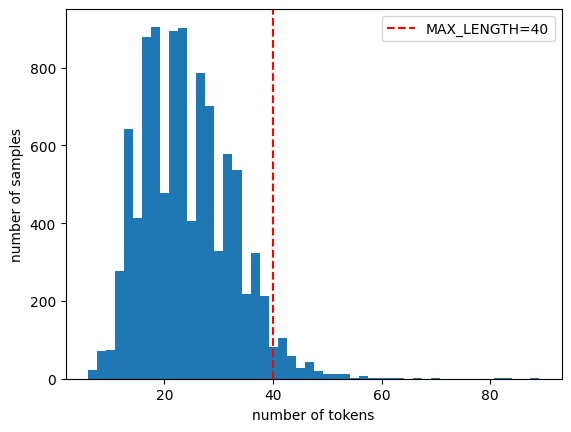

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

token_lengths = [len(tokenizer(t)["input_ids"]) for t in texts]
p95 = int(np.percentile(token_lengths, 95))
MAX_LENGTH = int(min(128, max(32, (p95 + 7) // 8 * 8)))
print(f"95th percentile of length: {p95} tokens | MAX_LENGTH = {MAX_LENGTH}")

fig, ax = plt.subplots()
ax.hist(token_lengths, bins=50)
ax.axvline(MAX_LENGTH, color="red", linestyle="--", label=f"MAX_LENGTH={MAX_LENGTH}")
ax.set_xlabel("number of tokens")
ax.set_ylabel("number of samples")
ax.legend()
plt.show()

## Dataset

In [ ]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=VAL_SIZE, random_state=SEED, stratify=labels
)


class HateSpeechDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        return {
            "input_ids": enc["input_ids"].flatten(),
            "attention_mask": enc["attention_mask"].flatten(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_ds = HateSpeechDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
val_ds = HateSpeechDataset(val_texts, val_labels, tokenizer, MAX_LENGTH)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
print(f"Training: {len(train_ds)} | Validation: {len(val_ds)}")

Training: 8032 | Validation: 2009


In [ ]:
class_weights = compute_class_weight("balanced", classes=np.unique(train_labels), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class weights: {class_weights.tolist()}")

Class weights: [0.5463201999664307, 5.897210121154785]


## Training and validation
The model is saved whenever it improves macro-F1 on the validation set.

In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        if criterion is not None:
            total_loss += criterion(logits, labels).item()
        all_preds.extend(torch.argmax(logits, dim=-1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader) if criterion is not None else None
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, macro_f1, np.array(all_preds), np.array(all_labels)

In [ ]:
def train_model(model, train_loader, val_loader, class_weights, epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY):
    model.to(device)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay
    )
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, int(total_steps * WARMUP_RATIO), total_steps
    )

    best_f1 = -1.0
    best_state = None
    history = {"train_loss": [], "val_loss": [], "val_f1": []}

    for epoch in range(epochs):
        model.train()
        running = 0.0
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            running += loss.item()

        train_loss = running / len(train_loader)
        val_loss, val_f1, _, _ = evaluate(model, val_loader, criterion)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)
        print(f"Epoch {epoch + 1}/{epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_macroF1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = deepcopy(model.state_dict())
            print(f"  New best macro-F1: {best_f1:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"Best macro-F1 (validation): {best_f1:.4f}")
    return model, history

## 5. Training - comparing fine-tuning methods

Four approaches trained and compared, the best one selected on validation macro-F1:

- **transfer** - frozen backbone, only the classification head is trained,
- **full** - full fine-tuning of every weight,
- **lora** - LoRA adapters (~1% of weights trained, low VRAM),
- **soft_prompt** - prompt tuning (only a handful of "virtual tokens" are learned).

Only the best method is used for the final predictions.

In [ ]:
def build_model(method="full", dropout=DROPOUT, classifier_dropout=CLASSIFIER_DROPOUT):
    config = AutoConfig.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        hidden_dropout_prob=dropout,
        attention_probs_dropout_prob=dropout,
        classifier_dropout=classifier_dropout,
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, config=config, ignore_mismatched_sizes=True
    )
    if method == "transfer":
        for p in model.base_model.parameters():
            p.requires_grad = False
    elif method == "full":
        pass  # all weights remain trainable
    elif method == "lora":
        peft_config = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            inference_mode=False,
            r=8,
            lora_alpha=32,
            lora_dropout=0.1,
            target_modules=["query", "value"],
        )
        model = get_peft_model(model, peft_config)
        model.print_trainable_parameters()
    elif method == "soft_prompt":
        from peft import PromptTuningConfig

        peft_config = PromptTuningConfig(
            task_type=TaskType.SEQ_CLS, num_virtual_tokens=20
        )
        model = get_peft_model(model, peft_config)
        model.print_trainable_parameters()
    else:
        raise ValueError(f"Unknown method: {method}")
    return model

In [ ]:
import gc

def clear_vram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

METHOD_CONFIGS = {
    "transfer":    dict(lr=1e-3, epochs=6,  weight_decay=0.01),
    "full":        dict(lr=2e-5, epochs=4,  weight_decay=0.01),
    "lora":        dict(lr=1e-4, epochs=5,  weight_decay=0.01),
    "soft_prompt": dict(lr=1e-2, epochs=12, weight_decay=0.0),
}
METHODS_TO_RUN = ["transfer", "full", "lora", "soft_prompt"]

results = {}
histories = {}
best_method = None
best_f1 = -1.0
model = None     # the best model for pred.csv
history = None

for method in METHODS_TO_RUN:
    cfg = METHOD_CONFIGS[method]
    print(f"\n========== Method: {method} (lr={cfg['lr']}, epochs={cfg['epochs']}) ==========")
    set_seed(SEED)
    candidate = build_model(method)
    candidate, h = train_model(
        candidate, train_loader, val_loader, class_weights,
        epochs=cfg["epochs"], lr=cfg["lr"], weight_decay=cfg["weight_decay"],
    )
    _, f1, _, _ = evaluate(candidate, val_loader)
    results[method] = f1
    histories[method] = h
    print(f"Method {method}: validation macro-F1 = {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_method = method
        if model is not None:
            del model
        model = candidate
        history = h
    else:
        del candidate
    clear_vram()

print("\n========== Summary (macro-F1 on validation) ==========")
for meth, f1 in sorted(results.items(), key=lambda kv: kv[1], reverse=True):
    mark = "   <-- best" if meth == best_method else ""
    print(f"{meth:12s}: {f1:.4f}{mark}")
print(f"\nBest method: {best_method} (macro-F1={best_f1:.4f})")


========== Method: transfer (lr=0.001, epochs=6) ==========


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.sso.sso_relationship.weight            | UNEXPECTED | 
cls.sso.sso_relationship.bias              | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those param

Epoch 1/6 | train_loss=0.6866 | val_loss=0.6403 | val_macroF1=0.5074
  New best macro-F1: 0.5074
Epoch 2/6 | train_loss=0.6616 | val_loss=0.6009 | val_macroF1=0.5850
  New best macro-F1: 0.5850
Epoch 3/6 | train_loss=0.6534 | val_loss=0.5932 | val_macroF1=0.5757
Epoch 4/6 | train_loss=0.6289 | val_loss=0.6059 | val_macroF1=0.5150
Epoch 5/6 | train_loss=0.6220 | val_loss=0.5868 | val_macroF1=0.6076
  New best macro-F1: 0.6076
Epoch 6/6 | train_loss=0.6075 | val_loss=0.5796 | val_macroF1=0.5942
Best macro-F1 (validation): 0.6076
Method transfer: validation macro-F1 = 0.6076

========== Method: full (lr=2e-05, epochs=4) ==========


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

[transformers] BertForSequenceClassification LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.sso.sso_relationship.weight            | UNEXPECTED | 
cls.sso.sso_relationship.bias              | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those param

trainable params: 296,450 || all params: 124,740,868 || trainable%: 0.2377
Epoch 1/5 | train_loss=0.6408 | val_loss=0.4970 | val_macroF1=0.6871
  New best macro-F1: 0.6871
Epoch 2/5 | train_loss=0.4970 | val_loss=0.4906 | val_macroF1=0.7164
  New best macro-F1: 0.7164
Epoch 3/5 | train_loss=0.4506 | val_loss=0.5008 | val_macroF1=0.7247
  New best macro-F1: 0.7247
Epoch 4/5 | train_loss=0.4139 | val_loss=0.5371 | val_macroF1=0.7321
  New best macro-F1: 0.7321
Epoch 5/5 | train_loss=0.4120 | val_loss=0.5953 | val_macroF1=0.7267
Best macro-F1 (validation): 0.7321
Method lora: validation macro-F1 = 0.7321

========== Method: soft_prompt (lr=0.01, epochs=12) ==========


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.sso.sso_relationship.weight            | UNEXPECTED | 
cls.sso.sso_relationship.bias              | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those param

trainable params: 16,898 || all params: 124,461,316 || trainable%: 0.0136
Epoch 1/12 | train_loss=0.8115 | val_loss=0.5704 | val_macroF1=0.5442
  New best macro-F1: 0.5442
Epoch 2/12 | train_loss=1.0374 | val_loss=0.5053 | val_macroF1=0.6210
  New best macro-F1: 0.6210
Epoch 3/12 | train_loss=0.9373 | val_loss=0.5435 | val_macroF1=0.5656
Epoch 4/12 | train_loss=0.9033 | val_loss=0.6239 | val_macroF1=0.6741
  New best macro-F1: 0.6741
Epoch 5/12 | train_loss=0.8134 | val_loss=1.1210 | val_macroF1=0.6537
Epoch 6/12 | train_loss=0.8050 | val_loss=0.5556 | val_macroF1=0.6701
Epoch 7/12 | train_loss=0.8192 | val_loss=0.5015 | val_macroF1=0.6438
Epoch 8/12 | train_loss=0.6808 | val_loss=0.5174 | val_macroF1=0.6949
  New best macro-F1: 0.6949
Epoch 9/12 | train_loss=0.6643 | val_loss=0.9513 | val_macroF1=0.6680
Epoch 10/12 | train_loss=0.5909 | val_loss=0.6643 | val_macroF1=0.6886
Epoch 11/12 | train_loss=0.5444 | val_loss=0.4681 | val_macroF1=0.6684
Epoch 12/12 | train_loss=0.5135 | val_loss

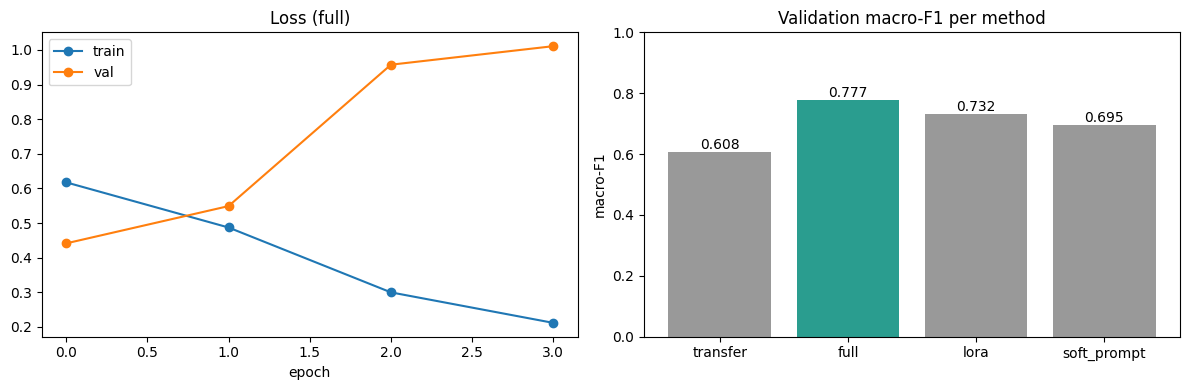

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], marker="o", label="train")
axes[0].plot(history["val_loss"], marker="o", label="val")
axes[0].set_title(f"Loss ({best_method})")
axes[0].set_xlabel("epoch")
axes[0].legend()

methods = list(results.keys())
f1s = [results[m] for m in methods]
colors = ["#2a9d8f" if m == best_method else "#999999" for m in methods]
bars = axes[1].bar(methods, f1s, color=colors)
axes[1].set_title("Validation macro-F1 per method")
axes[1].set_ylabel("macro-F1")
axes[1].set_ylim(0, 1)
for b, f1 in zip(bars, f1s):
    axes[1].text(b.get_x() + b.get_width() / 2, f1 + 0.01, f"{f1:.3f}", ha="center")

plt.tight_layout()
plt.show()

## Ewaluacja

In [ ]:
_, val_f1, val_preds, val_true = evaluate(model, val_loader)
print(f"Macro-F1: {val_f1:.4f}")
print(f"Accuracy: {accuracy_score(val_true, val_preds):.4f}")
print()
print(classification_report(val_true, val_preds, target_names=["Non-hate (0)", "Hate (1)"], zero_division=0))
print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(val_true, val_preds))

Macro-F1: 0.7773
Accuracy: 0.9308

              precision    recall  f1-score   support

Non-hate (0)       0.96      0.96      0.96      1839
    Hate (1)       0.59      0.59      0.59       170

    accuracy                           0.93      2009
   macro avg       0.78      0.78      0.78      2009
weighted avg       0.93      0.93      0.93      2009

Confusion matrix (rows=true, cols=pred):
[[1769   70]
 [  69  101]]


## Choosing the decision threshold

The classes are imbalanced, so moving the threshold away from 0.5 can raise macro-F1.

The threshold is selected on the validation set only, then applied to the test predictions.

Default threshold 0.50    -> macro-F1 = 0.7773
Tuned threshold 0.39    -> macro-F1 = 0.7817  (gain: +0.0044)


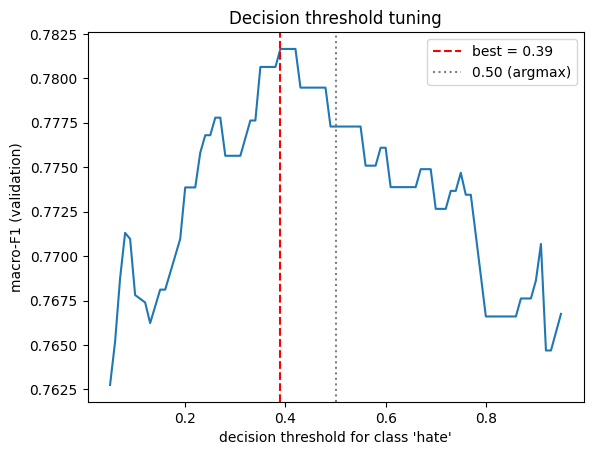

              precision    recall  f1-score   support

Non-hate (0)       0.96      0.96      0.96      1839
    Hate (1)       0.60      0.61      0.60       170

    accuracy                           0.93      2009
   macro avg       0.78      0.78      0.78      2009
weighted avg       0.93      0.93      0.93      2009

Confusion matrix (tuned threshold):
[[1769   70]
 [  67  103]]


In [ ]:
@torch.no_grad()
def predict_proba(model, loader):
    model.eval()
    probs, labels_out = [], []
    has_labels = False
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        probs.extend(torch.softmax(logits, dim=-1)[:, 1].cpu().numpy())
        if "labels" in batch:
            labels_out.extend(batch["labels"].numpy())
            has_labels = True
    return np.array(probs), (np.array(labels_out) if has_labels else None)


val_probs, val_lab = predict_proba(model, val_loader)
thresholds = np.linspace(0.05, 0.95, 91)
f1_by_t = [
    f1_score(val_lab, (val_probs >= t).astype(int), average="macro", zero_division=0)
    for t in thresholds
]
best_idx = int(np.argmax(f1_by_t))
BEST_THRESHOLD = float(thresholds[best_idx])

f1_default = f1_score(val_lab, (val_probs >= 0.5).astype(int), average="macro", zero_division=0)
print(f"Default threshold 0.50    -> macro-F1 = {f1_default:.4f}")
print(f"Tuned threshold {BEST_THRESHOLD:.2f}    -> macro-F1 = {f1_by_t[best_idx]:.4f}  (gain: {f1_by_t[best_idx] - f1_default:+.4f})")

fig, ax = plt.subplots()
ax.plot(thresholds, f1_by_t)
ax.axvline(BEST_THRESHOLD, color="red", linestyle="--", label=f"best = {BEST_THRESHOLD:.2f}")
ax.axvline(0.5, color="gray", linestyle=":", label="0.50 (argmax)")
ax.set_xlabel("decision threshold for class 'hate'")
ax.set_ylabel("macro-F1 (validation)")
ax.set_title("Decision threshold tuning")
ax.legend()
plt.show()

# Detailed report at the tuned threshold
val_preds_t = (val_probs >= BEST_THRESHOLD).astype(int)
print(classification_report(val_lab, val_preds_t, target_names=["Non-hate (0)", "Hate (1)"], zero_division=0))
print("Confusion matrix (tuned threshold):")
print(confusion_matrix(val_lab, val_preds_t))

## Predykcja na zbiorze testowym

In [ ]:
with open("hate_test_data.txt", encoding="utf-8") as f:
    raw_lines = f.read().splitlines()
test_texts = [preprocess_text(line) for line in raw_lines]
print(f"Test samples: {len(test_texts)}")


class TestDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        return {
            "input_ids": enc["input_ids"].flatten(),
            "attention_mask": enc["attention_mask"].flatten(),
        }


test_loader = DataLoader(TestDataset(test_texts, tokenizer, MAX_LENGTH), batch_size=32, shuffle=False)

# Class 'hate' probabilities with the tuned decision threshold (instead of raw argmax)
test_probs, _ = predict_proba(model, test_loader)
test_preds = (test_probs >= BEST_THRESHOLD).astype(int)

pred_series = pd.Series(test_preds, dtype=int)
pred_series.to_csv("pred.csv", index=False, header=False)
print(f"Saved pred.csv: {len(pred_series)} rows (threshold={BEST_THRESHOLD:.2f})")

Test samples: 1000
Saved pred.csv: 1000 rows (threshold=0.39)


In [ ]:
check = pd.read_csv("pred.csv", header=None)
print(check[0].value_counts())

0
0    903
1     97
Name: count, dtype: int64
